# NumCompute-Stream Demo: Streaming Decision Trees and Ensembles

This notebook demonstrates the Assignment 2.2 streaming classification workflow using the custom `numcompute` package.

## Dataset roles

**Primary streaming model dataset:** `data/Iris.csv`

Iris is used for the main model-training demo because it is clean, numeric, balanced, and easy to verify. This makes it useful for checking that the streaming `Pipeline`, `DecisionTreeClassifier`, and tree ensembles work correctly.

**Secondary dataset analysis:** `data/sleep_data.csv`

Sleep is used later for HD-level dataset-condition analysis because it contains mixed numeric/categorical features, missing values, and class imbalance. This supports the preprocessing and visualisation parts of the rubric.

The notebook therefore shows both:
- a stable streaming model experiment on Iris;
- extra real-world data diagnostics on Sleep.


## 1. Imports, paths, and reproducibility

The notebook can be run from either the project root or the `demo/` folder.

Only standard Python, NumPy, matplotlib, and local `numcompute` modules are used.


In [2]:
# Standard library imports
import os
import sys
import csv
import inspect
from pathlib import Path

# Project root detection
CURRENT_DIR = Path(os.getcwd()).resolve()

if CURRENT_DIR.name.lower() == "demo":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

# Allowed libraries
import numpy as np
import matplotlib.pyplot as plt

# NumCompute modules
from numcompute.io import read_csv
from numcompute.preprocessing import StandardScaler, ColumnTransformer
from numcompute.pipeline import Pipeline
from numcompute.tree import DecisionTreeClassifier
from numcompute.ensemble import (
    OnlineBaggingClassifier,
    RandomForestClassifier,
    RandomSubspaceClassifier,
    ExtraTreesClassifier,
    AdaBoostSAMMEClassifier,
)
from numcompute.stream import StreamTrainer
from numcompute.metrics import (
    accuracy,
    macro_f1,
    weighted_f1,
    confusion_matrix,
)
from numcompute.visualise import (
    plot_metric_over_time,
    plot_model_comparison,
    plot_predictions_vs_ground_truth,
    plot_class_distribution,
    plot_class_distribution_over_time,
    plot_confusion_matrix,
    plot_missing_values,
)

RANDOM_STATE = 42
N_ESTIMATORS = 5  # Keeps the demo fast; benchmarking can use larger ensembles.
np.random.seed(RANDOM_STATE)

DATA_DIR = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "demo" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Figure output directory:", FIG_DIR)
print("Random seed:", RANDOM_STATE)
print("Demo ensemble size:", N_ESTIMATORS)


Project root: D:\Programming for Aritificial Intelligence\NumCompute-Stream\NumCompute - temp
Data directory: D:\Programming for Aritificial Intelligence\NumCompute-Stream\NumCompute - temp\data
Figure output directory: D:\Programming for Aritificial Intelligence\NumCompute-Stream\NumCompute - temp\demo\figures
Random seed: 42
Demo ensemble size: 5


## 2. Load the primary dataset using `io.py`

The assignment requires the notebook to load a CSV using the custom I/O module.

This section uses:

```python
from numcompute.io import read_csv
```

The main streaming task is **multi-class classification** of Iris species.


In [3]:
iris_path = DATA_DIR / "Iris.csv"

if not iris_path.exists():
    raise FileNotFoundError(
        f"Expected Iris dataset at {iris_path}. "
        "Place Iris.csv in the data/ folder."
    )

raw_iris = read_csv(iris_path)
raw_iris = np.asarray(raw_iris, dtype=object)

if raw_iris.ndim != 2:
    raise ValueError("Expected Iris.csv to load as a 2D table")

iris_header = raw_iris[0]
iris_rows = raw_iris[1:]

print("Primary streaming dataset:", iris_path.name)
print("Task type: multi-class classification")
print("Raw shape after header removal:", iris_rows.shape)
print("Header:", iris_header)
print("\nFirst 5 rows:")
print(iris_rows[:5])


Primary streaming dataset: Iris.csv
Task type: multi-class classification
Raw shape after header removal: (150, 6)
Header: ['Id' 'SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm'
 'Species']

First 5 rows:
[['1' '5.1' '3.5' '1.4' '0.2' 'Iris-setosa']
 ['2' '4.9' '3.0' '1.4' '0.2' 'Iris-setosa']
 ['3' '4.7' '3.2' '1.3' '0.2' 'Iris-setosa']
 ['4' '4.6' '3.1' '1.5' '0.2' 'Iris-setosa']
 ['5' '5.0' '3.6' '1.4' '0.2' 'Iris-setosa']]


## 3. Prepare Iris features and target

Important cleaning choices:

1. `Id` is dropped because it is an identifier and can cause leakage-like shortcuts.
2. `Species` is used as the target.
3. Species names are encoded to integer class labels for the models and metrics.

No scaler or model is fitted yet.


In [4]:
def prepare_iris_dataset(rows, header):
    """
    Prepare Iris features and target labels.

    Returns
    -------
    X : ndarray of shape (n_samples, n_features)
        Numeric feature matrix with identifier columns removed.
    y : ndarray of shape (n_samples,)
        Numeric target labels.
    classes : ndarray
        Original class names corresponding to y values.
    feature_names : ndarray
        Names of numeric feature columns.
    """
    header = np.asarray(header, dtype=object)
    rows = np.asarray(rows, dtype=object)

    target_idx = int(np.where(header == "Species")[0][0])

    feature_indices = []
    feature_names = []

    for idx, name in enumerate(header):
        name_text = str(name).strip()

        if idx == target_idx:
            continue
        if name_text.lower() == "id":
            continue

        feature_indices.append(idx)
        feature_names.append(name_text)

    X = rows[:, feature_indices].astype(float)
    y_text = rows[:, target_idx].astype(str)

    classes, y = np.unique(y_text, return_inverse=True)

    return X, y, classes, np.asarray(feature_names, dtype=object)


X, y, iris_classes, iris_feature_names = prepare_iris_dataset(iris_rows, iris_header)

print("Prepared X shape:", X.shape)
print("Prepared y shape:", y.shape)
print("Feature names:", iris_feature_names)
print("Class names:", iris_classes)

print("\nClass mapping:")
for idx, label in enumerate(iris_classes):
    print(f"{idx} = {label}")


Prepared X shape: (150, 4)
Prepared y shape: (150,)
Feature names: ['SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm']
Class names: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Class mapping:
0 = Iris-setosa
1 = Iris-versicolor
2 = Iris-virginica


## 4. Dataset-condition analysis before training

For HD-level presentation, briefly inspect the dataset before modelling.

Iris is balanced, which means accuracy is more meaningful here than it would be on an imbalanced dataset.  
The Sleep dataset later shows the imbalanced case.


Iris class counts:
Iris-setosa: 50
Iris-versicolor: 50
Iris-virginica: 50

Imbalance ratio max/min: 1.0
Missing numeric values: 0


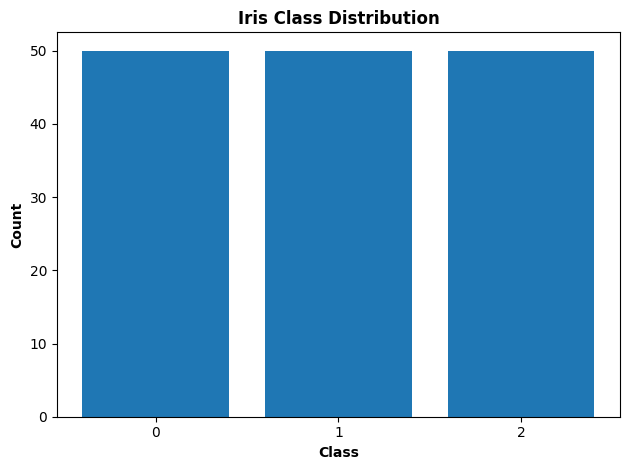

In [5]:
def class_counts(y, classes):
    return np.asarray([np.sum(y == i) for i in range(len(classes))], dtype=int)


iris_counts = class_counts(y, iris_classes)
iris_imbalance_ratio = iris_counts.max() / max(iris_counts.min(), 1)

print("Iris class counts:")
for label, count in zip(iris_classes, iris_counts):
    print(f"{label}: {count}")

print("\nImbalance ratio max/min:", round(float(iris_imbalance_ratio), 3))
print("Missing numeric values:", int(np.sum(np.isnan(X))))

_ = plot_class_distribution(
    y,
    classes=np.arange(len(iris_classes)),
    title="Iris Class Distribution",
    save_path=str(FIG_DIR / "iris_class_distribution.png"),
    show=True,
)


## 5. Train/test split before chunking

The correct experimental order is:

```text
CSV load
→ prepare X and y
→ train/test split
→ split training set into stream chunks
→ partial_fit() chunk by chunk
→ final evaluation on held-out test set
```

The test set is not used during streaming training.  
This avoids overly optimistic evaluation.


In [6]:
def stratified_train_test_split(X, y, test_size=0.25, random_state=42):
    """
    Create a stratified train/test split using only NumPy.
    """
    if not 0 < test_size < 1:
        raise ValueError("test_size must be between 0 and 1")

    X = np.asarray(X)
    y = np.asarray(y)

    rng = np.random.default_rng(random_state)

    train_indices = []
    test_indices = []

    for cls in np.unique(y):
        cls_indices = np.where(y == cls)[0]
        rng.shuffle(cls_indices)

        n_test = int(round(len(cls_indices) * test_size))
        n_test = max(1, min(n_test, len(cls_indices) - 1))

        test_indices.extend(cls_indices[:n_test].tolist())
        train_indices.extend(cls_indices[n_test:].tolist())

    train_indices = np.asarray(train_indices, dtype=int)
    test_indices = np.asarray(test_indices, dtype=int)

    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]


X_train, X_test, y_train, y_test = stratified_train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class counts:")
for label, count in zip(iris_classes, class_counts(y_train, iris_classes)):
    print(f"{label}: {count}")

print("\nTest class counts:")
for label, count in zip(iris_classes, class_counts(y_test, iris_classes)):
    print(f"{label}: {count}")


Training shape: (114, 4)
Test shape: (36, 4)

Training class counts:
Iris-setosa: 38
Iris-versicolor: 38
Iris-virginica: 38

Test class counts:
Iris-setosa: 12
Iris-versicolor: 12
Iris-virginica: 12


## 6. Split the training data into stream chunks

Only the training set is chunked.  
This simulates data arriving in batches over time.


Number of stream chunks: 5
Chunk 1: X=(23, 4), y=(23,), class counts=[7 7 9]
Chunk 2: X=(23, 4), y=(23,), class counts=[ 6 10  7]
Chunk 3: X=(23, 4), y=(23,), class counts=[ 5 10  8]
Chunk 4: X=(23, 4), y=(23,), class counts=[13  4  6]
Chunk 5: X=(22, 4), y=(22,), class counts=[7 7 8]


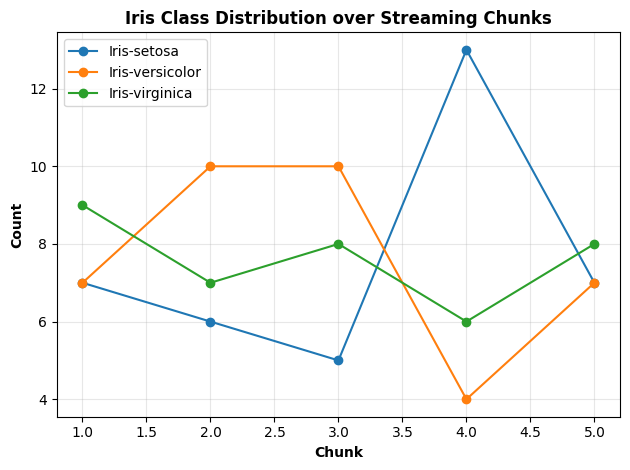

In [7]:
def make_stream_chunks(X, y, n_chunks=5):
    """
    Split arrays into streaming chunks.
    """
    if n_chunks <= 0:
        raise ValueError("n_chunks must be positive")

    X_chunks = np.array_split(X, n_chunks)
    y_chunks = np.array_split(y, n_chunks)

    return list(zip(X_chunks, y_chunks))


N_CHUNKS = 5
train_chunks = make_stream_chunks(X_train, y_train, n_chunks=N_CHUNKS)

print("Number of stream chunks:", len(train_chunks))

for i, (X_chunk, y_chunk) in enumerate(train_chunks, start=1):
    print(
        f"Chunk {i}: X={X_chunk.shape}, y={y_chunk.shape}, "
        f"class counts={class_counts(y_chunk, iris_classes)}"
    )

counts_by_chunk = np.asarray([
    class_counts(y_chunk, iris_classes)
    for _, y_chunk in train_chunks
])

_ = plot_class_distribution_over_time(
    counts_by_chunk,
    classes=iris_classes,
    title="Iris Class Distribution over Streaming Chunks",
    save_path=str(FIG_DIR / "iris_class_distribution_over_chunks.png"),
    show=True,
)


## 7. Build a stream-compatible pipeline

The model pipeline is:

```text
StandardScaler.partial_fit()
→ DecisionTreeClassifier or ensemble.partial_fit()
```

The helper below keeps the notebook compatible with both the original and extended `Pipeline` APIs.


In [8]:
def make_pipeline(steps):
    """
    Create a Pipeline with optional streaming-safe keyword arguments when available.
    """
    kwargs = {}
    pipeline_params = inspect.signature(Pipeline).parameters

    if "allow_fit_fallback" in pipeline_params:
        kwargs["allow_fit_fallback"] = True

    if "rebuild_on_feature_change" in pipeline_params:
        kwargs["rebuild_on_feature_change"] = True

    return Pipeline(steps, **kwargs)


def build_streaming_pipeline(model):
    """
    Create a scaling + classifier pipeline.
    """
    return make_pipeline([
        ("scale", StandardScaler()),
        ("model", model),
    ])


def balanced_accuracy_multiclass(y_true, y_pred, classes):
    """
    Compute macro-average recall across classes.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    recalls = []

    for cls in classes:
        mask = y_true == cls
        if np.any(mask):
            recalls.append(np.mean(y_pred[mask] == cls))

    return float(np.mean(recalls)) if recalls else 0.0


all_class_indices = np.arange(len(iris_classes))


## 8. Prequential streaming evaluation

For a stronger streaming demo, this notebook uses **test-then-train** evaluation:

```text
first chunk: fit only, because the model has no state yet
later chunks: predict chunk → log metric → partial_fit on that chunk
```

This is stricter than training on a chunk and then scoring the same chunk.


In [9]:
def run_streaming_experiment(model_name, model, chunks, X_test, y_test, classes):
    """
    Run one model under a prequential streaming protocol.
    """
    pipeline = build_streaming_pipeline(model)

    trainer = StreamTrainer(
        model=pipeline,
        classes=classes,
        track_memory=True,
    )

    prequential_accuracy = []
    prequential_error = []
    evaluated_chunk_numbers = []

    for chunk_id, (X_chunk, y_chunk) in enumerate(chunks, start=1):
        if chunk_id == 1:
            trainer.fit_chunk(X_chunk, y_chunk)
            print(f"{model_name}: chunk {chunk_id} used as warm-up fit chunk")
            continue

        # Test-then-train: score before updating on this chunk.
        metrics = trainer.score_chunk(X_chunk, y_chunk)
        prequential_accuracy.append(metrics["chunk_accuracy"])
        prequential_error.append(1.0 - metrics["chunk_accuracy"])
        evaluated_chunk_numbers.append(chunk_id)

        trainer.fit_chunk(X_chunk, y_chunk)

    y_test_pred = pipeline.predict(X_test)

    final = {
        "model": model_name,
        "prequential_accuracy": prequential_accuracy,
        "prequential_error": prequential_error,
        "evaluated_chunk_numbers": evaluated_chunk_numbers,
        "test_accuracy": accuracy(y_test, y_test_pred),
        "macro_f1": macro_f1(y_test, y_test_pred),
        "weighted_f1": weighted_f1(y_test, y_test_pred),
        "balanced_accuracy": balanced_accuracy_multiclass(y_test, y_test_pred, classes),
        "test_predictions": y_test_pred,
        "logs": trainer.get_logs(),
    }

    return final, pipeline, trainer


## 9. Baseline model: single decision tree

The single decision tree is the baseline.  
The ensembles should usually improve stability, but they do not have to win every chunk.


Decision Tree: chunk 1 used as warm-up fit chunk

Decision Tree final held-out test metrics:
Test accuracy: 0.9444
Macro F1: 0.9444
Weighted F1: 0.9444
Balanced accuracy: 0.9444

Prequential chunk accuracy:
[np.float64(0.8260869565217391), np.float64(0.9565217391304348), np.float64(1.0), np.float64(0.9545454545454546)]


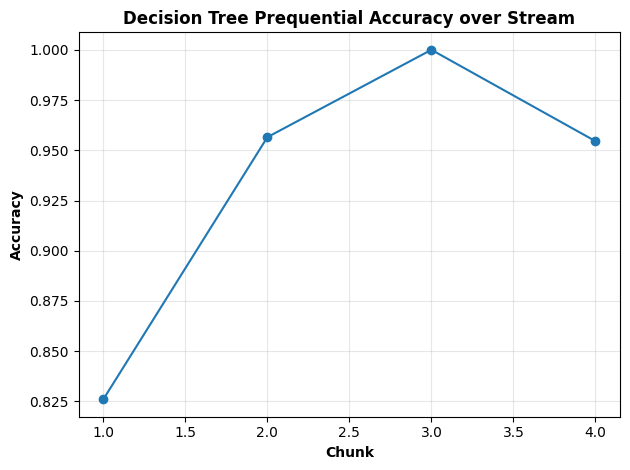

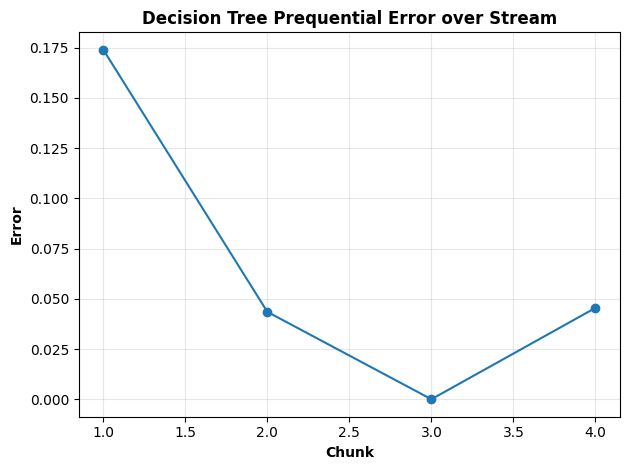

In [10]:
tree_result, tree_pipeline, tree_trainer = run_streaming_experiment(
    "Decision Tree",
    DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=2,
        criterion="gini",
        random_state=RANDOM_STATE,
    ),
    train_chunks,
    X_test,
    y_test,
    all_class_indices,
)

print("\nDecision Tree final held-out test metrics:")
print("Test accuracy:", round(tree_result["test_accuracy"], 4))
print("Macro F1:", round(tree_result["macro_f1"], 4))
print("Weighted F1:", round(tree_result["weighted_f1"], 4))
print("Balanced accuracy:", round(tree_result["balanced_accuracy"], 4))

print("\nPrequential chunk accuracy:")
print(tree_result["prequential_accuracy"])

_ = plot_metric_over_time(
    tree_result["prequential_accuracy"],
    title="Decision Tree Prequential Accuracy over Stream",
    ylabel="Accuracy",
    save_path=str(FIG_DIR / "tree_preq_accuracy.png"),
    show=True,
)

_ = plot_metric_over_time(
    tree_result["prequential_error"],
    title="Decision Tree Prequential Error over Stream",
    ylabel="Error",
    save_path=str(FIG_DIR / "tree_preq_error.png"),
    show=True,
)


## 10. Inspect `StreamTrainer` logs

The logs show chunk-level fit/score records, including memory and timing.


In [11]:
tree_logs = tree_trainer.get_logs()

print("Number of log records:", len(tree_logs))
print("\nFirst 6 log records:")
for row in tree_logs[:6]:
    print(row)

print("\nFit-time and memory summary:")
for row in tree_logs:
    if row.get("event") == "fit":
        print(
            "Chunk:", row["chunk"],
            "| samples:", row["n_samples"],
            "| fit_time:", round(row["fit_time"], 6),
            "| peak_memory_mb:", round(row["peak_memory_mb"], 6),
        )


Number of log records: 9

First 6 log records:
{'chunk': 1, 'event': 'fit', 'n_samples': 23, 'n_samples_seen': 23, 'fit_time': 0.01521549979224801, 'current_memory_mb': 0.16387271881103516, 'peak_memory_mb': 0.17179393768310547}
{'chunk': 1, 'event': 'score', 'n_samples': 23, 'chunk_accuracy': np.float64(0.8260869565217391), 'cumulative_accuracy': 0.8260869565217391, 'score_time': 5.759997293353081e-05, 'confusion_matrix': array([[6, 0, 0],
       [0, 7, 3],
       [0, 1, 6]])}
{'chunk': 2, 'event': 'fit', 'n_samples': 23, 'n_samples_seen': 46, 'fit_time': 0.03882799996063113, 'current_memory_mb': 0.15877819061279297, 'peak_memory_mb': 0.17028141021728516}
{'chunk': 2, 'event': 'score', 'n_samples': 23, 'chunk_accuracy': np.float64(0.9565217391304348), 'cumulative_accuracy': 0.8913043478260869, 'score_time': 6.150011904537678e-05, 'confusion_matrix': array([[5, 0, 0],
       [0, 9, 1],
       [0, 0, 8]])}
{'chunk': 3, 'event': 'fit', 'n_samples': 23, 'n_samples_seen': 69, 'fit_time': 0

## 11. Compare base tree and ensemble models

This section compares:

- `DecisionTreeClassifier`
- `OnlineBaggingClassifier`
- `RandomForestClassifier`
- `RandomSubspaceClassifier`
- `ExtraTreesClassifier`
- `AdaBoostSAMMEClassifier`

All models use the same train/test split, same stream chunks, same scaler, and same prequential protocol.


In [12]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        random_state=RANDOM_STATE,
    ),
    "Online Bagging": OnlineBaggingClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=4,
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=4,
        max_features="sqrt",
        random_state=RANDOM_STATE,
    ),
    "Random Subspace": RandomSubspaceClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=4,
        max_features="sqrt",
        random_state=RANDOM_STATE,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=4,
        max_features="sqrt",
        random_state=RANDOM_STATE,
    ),
    "AdaBoost SAMME": AdaBoostSAMMEClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=1,
        random_state=RANDOM_STATE,
    ),
}

results = {}
pipelines = {}
trainers = {}

for name, model in models.items():
    print("\nRunning:", name)

    result, fitted_pipeline, fitted_trainer = run_streaming_experiment(
        name,
        model,
        train_chunks,
        X_test,
        y_test,
        all_class_indices,
    )

    results[name] = result
    pipelines[name] = fitted_pipeline
    trainers[name] = fitted_trainer

metric_history = {
    name: result["prequential_accuracy"]
    for name, result in results.items()
}

print("\nFinal held-out test results:")
print(f"{'Model':<18} {'Test Acc':<10} {'Macro F1':<10} {'Weighted F1':<12} {'Bal Acc':<10}")
print("-" * 65)

for name, result in results.items():
    print(
        f"{name:<18} "
        f"{result['test_accuracy']:<10.4f} "
        f"{result['macro_f1']:<10.4f} "
        f"{result['weighted_f1']:<12.4f} "
        f"{result['balanced_accuracy']:<10.4f}"
    )



Running: Decision Tree
Decision Tree: chunk 1 used as warm-up fit chunk

Running: Online Bagging
Online Bagging: chunk 1 used as warm-up fit chunk

Running: Random Forest
Random Forest: chunk 1 used as warm-up fit chunk

Running: Random Subspace
Random Subspace: chunk 1 used as warm-up fit chunk

Running: Extra Trees
Extra Trees: chunk 1 used as warm-up fit chunk

Running: AdaBoost SAMME
AdaBoost SAMME: chunk 1 used as warm-up fit chunk

Final held-out test results:
Model              Test Acc   Macro F1   Weighted F1  Bal Acc   
-----------------------------------------------------------------
Decision Tree      0.9444     0.9444     0.9444       0.9444    
Online Bagging     0.9444     0.9444     0.9444       0.9444    
Random Forest      0.9167     0.9165     0.9165       0.9167    
Random Subspace    0.9167     0.9165     0.9165       0.9167    
Extra Trees        0.8611     0.8609     0.8609       0.8611    
AdaBoost SAMME     0.8889     0.8861     0.8861       0.8889    


## 12. Visualise model comparison

The required `visualise.py` function `plot_model_comparison()` is used to compare chunk-wise model performance.


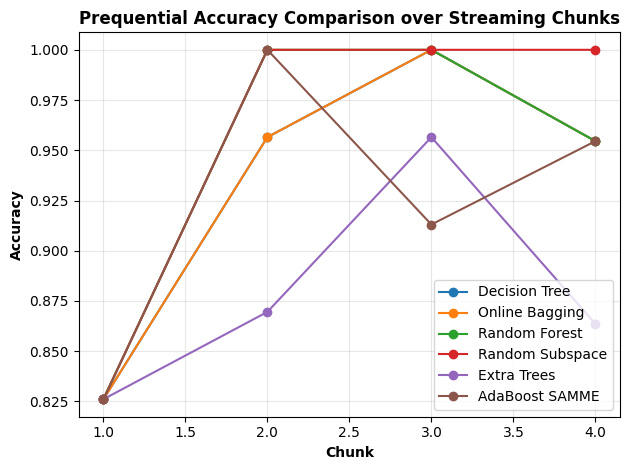

In [13]:
_ = plot_model_comparison(
    metric_history,
    title="Prequential Accuracy Comparison over Streaming Chunks",
    ylabel="Accuracy",
    save_path=str(FIG_DIR / "model_preq_accuracy_comparison.png"),
    show=True,
)


## 13. Final held-out test interpretation

The best model is selected by held-out **macro-F1**.  
For Iris, macro-F1 and accuracy are usually similar because the classes are balanced, but macro-F1 is still reported for consistency with imbalanced datasets.


Best model by macro-F1: Decision Tree
Test accuracy: 0.9444
Macro F1: 0.9444
Balanced accuracy: 0.9444


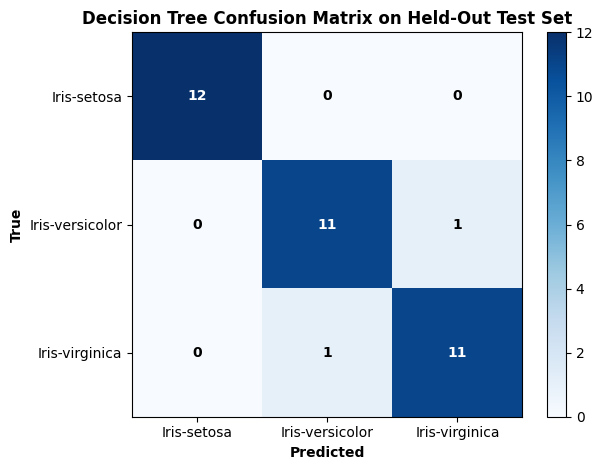

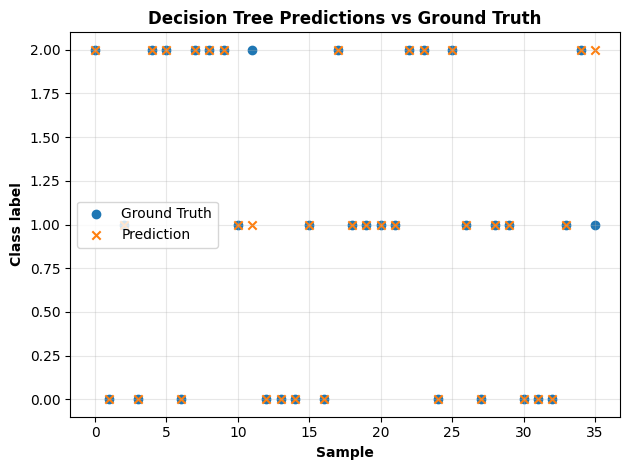

In [14]:
best_model_name = max(results, key=lambda name: results[name]["macro_f1"])
best_result = results[best_model_name]
best_pred = best_result["test_predictions"]

best_cm = confusion_matrix(y_test, best_pred, classes=all_class_indices)

print("Best model by macro-F1:", best_model_name)
print("Test accuracy:", round(best_result["test_accuracy"], 4))
print("Macro F1:", round(best_result["macro_f1"], 4))
print("Balanced accuracy:", round(best_result["balanced_accuracy"], 4))

_ = plot_confusion_matrix(
    best_cm,
    classes=iris_classes,
    normalize=False,
    title=f"{best_model_name} Confusion Matrix on Held-Out Test Set",
    save_path=str(FIG_DIR / "best_model_confusion_matrix.png"),
    show=True,
)

_ = plot_predictions_vs_ground_truth(
    y_test,
    best_pred,
    title=f"{best_model_name} Predictions vs Ground Truth",
    save_path=str(FIG_DIR / "best_model_predictions_vs_ground_truth.png"),
    show=True,
)


## 14. Secondary dataset analysis: Sleep

The Sleep dataset is not the main training demo in this notebook, but it is useful for showing dataset-condition analysis and mixed-data preprocessing.

This section demonstrates:

- loading a second CSV through `io.py`;
- checking missing values;
- checking target imbalance;
- using `ColumnTransformer.partial_fit()` on mixed numeric/categorical data.

The target value `"None"` means **no sleep disorder** and should be treated as a valid class.


Secondary dataset: sleep_data.csv
Sleep shape: (374, 13)
Target classes: ['Insomnia' 'None' 'Sleep Apnea']

Sleep class counts:
Insomnia: 77
None: 219
Sleep Apnea: 78

Sleep imbalance ratio max/min: 2.844
Feature-level missing-like values: 15


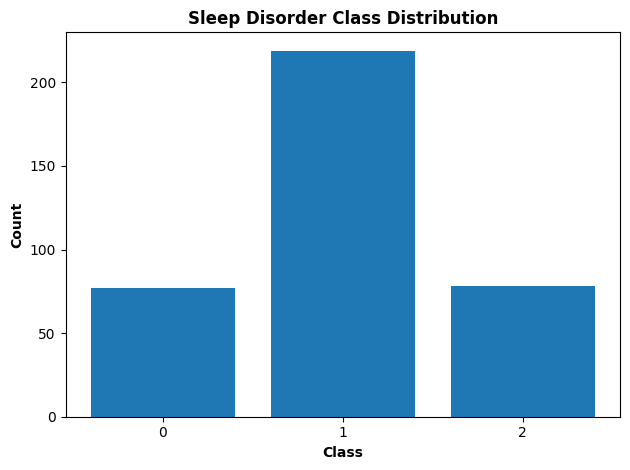

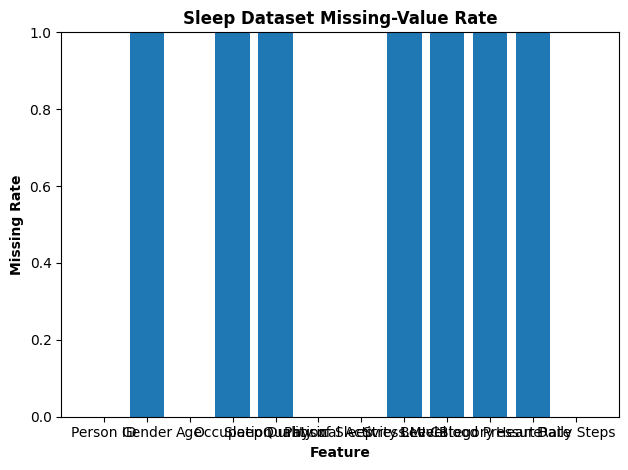

In [15]:
sleep_path = DATA_DIR / "sleep_data.csv"

MISSING_TOKENS = {"", "nan", "NaN", "NA", "N/A", "?"}


def is_missing_feature_value(value):
    if isinstance(value, float) and np.isnan(value):
        return True
    return str(value).strip() in MISSING_TOKENS


def count_missing_like(data):
    arr = np.asarray(data, dtype=object)
    missing = np.zeros(arr.shape, dtype=bool)

    for index, value in np.ndenumerate(arr):
        missing[index] = is_missing_feature_value(value)

    return int(np.sum(missing))


if sleep_path.exists():
    raw_sleep = read_csv(sleep_path)
    raw_sleep = np.asarray(raw_sleep, dtype=object)

    sleep_header = raw_sleep[0]
    sleep_rows = raw_sleep[1:]

    X_sleep = sleep_rows[:, :-1]
    y_sleep_text = sleep_rows[:, -1].astype(str)
    sleep_classes, y_sleep = np.unique(y_sleep_text, return_inverse=True)

    print("Secondary dataset:", sleep_path.name)
    print("Sleep shape:", sleep_rows.shape)
    print("Target classes:", sleep_classes)

    sleep_counts = class_counts(y_sleep, sleep_classes)
    print("\nSleep class counts:")
    for label, count in zip(sleep_classes, sleep_counts):
        print(f"{label}: {count}")

    print("\nSleep imbalance ratio max/min:", round(float(sleep_counts.max() / max(sleep_counts.min(), 1)), 3))
    print("Feature-level missing-like values:", count_missing_like(X_sleep))

    _ = plot_class_distribution(
        y_sleep,
        classes=np.arange(len(sleep_classes)),
        title="Sleep Disorder Class Distribution",
        save_path=str(FIG_DIR / "sleep_class_distribution.png"),
        show=True,
    )

    _ = plot_missing_values(
        X_sleep,
        feature_names=sleep_header[:-1],
        title="Sleep Dataset Missing-Value Rate",
        save_path=str(FIG_DIR / "sleep_missing_values.png"),
        show=True,
    )
else:
    print("Sleep dataset not found. Skipping secondary dataset analysis.")


## 15. Streaming mixed-data preprocessing demonstration

This section shows `ColumnTransformer.partial_fit()` on Sleep chunks.

This is not used for final model comparison here because the main model experiment uses Iris for a clean and stable numeric classification demonstration.


In [16]:
if sleep_path.exists():
    # Drop the identifier and target columns for the preprocessing demonstration.
    sleep_feature_header = sleep_header[:-1]
    keep_cols = [
        idx for idx, name in enumerate(sleep_feature_header)
        if str(name).strip().lower() not in {"person id", "id"}
    ]

    X_sleep_features = X_sleep[:, keep_cols]
    kept_feature_names = sleep_feature_header[keep_cols]

    sleep_chunks = np.array_split(X_sleep_features, 3)

    ct = ColumnTransformer()

    for i, X_sleep_chunk in enumerate(sleep_chunks, start=1):
        ct.partial_fit(X_sleep_chunk)
        X_sleep_transformed = ct.transform(X_sleep_chunk)

        print(f"\nAfter Sleep preprocessing chunk {i}:")
        print("Detected numeric columns:", ct.num_cols)
        print("Detected categorical columns:", ct.cat_cols)
        print("Transformed shape:", X_sleep_transformed.shape)
else:
    print("Sleep dataset not found. Skipping ColumnTransformer demo.")



After Sleep preprocessing chunk 1:
Detected numeric columns: [1, 4, 5, 10]
Detected categorical columns: [0, 2, 3, 6, 7, 8, 9]
Transformed shape: (125, 77)

After Sleep preprocessing chunk 2:
Detected numeric columns: [1, 4, 5, 10]
Detected categorical columns: [0, 2, 3, 6, 7, 8, 9]
Transformed shape: (125, 89)

After Sleep preprocessing chunk 3:
Detected numeric columns: [1, 4, 5, 10]
Detected categorical columns: [0, 2, 3, 6, 7, 8, 9]
Transformed shape: (124, 101)


## 16. Benchmark review

The separate benchmark script can be run from the project root:

```bash
python benchmarking/benchmarking.py
```

That script should compare models over one or more datasets and save `benchmarking/benchmark_results.csv`.


In [17]:
benchmark_csv = BASE_DIR / "benchmarking" / "benchmark_results.csv"

if benchmark_csv.exists():
    print("Benchmark results loaded from:", benchmark_csv)

    with open(benchmark_csv, newline="") as f:
        reader = csv.DictReader(f)
        rows = list(reader)

    if rows:
        preferred_cols = [
            "dataset",
            "model",
            "chunks",
            "evaluated_chunks",
            "fit_time",
            "pred_time",
            "total_time",
            "memory_mb",
            "prequential_chunk_accuracy",
            "prequential_cumulative_accuracy",
            "chunk_accuracy",
            "cumulative_accuracy",
            "test_accuracy",
            "macro_f1",
            "balanced_accuracy",
            "latency_ms_per_sample",
        ]

        columns_to_show = [col for col in preferred_cols if col in rows[0]]

        print("\nBenchmark summary:")
        print(" | ".join(columns_to_show))
        print("-" * 160)

        for row in rows:
            print(" | ".join(str(row.get(col, ""))[:18] for col in columns_to_show))
    else:
        print("Benchmark CSV exists but is empty.")
else:
    print("Benchmark CSV not found.")
    print("Run this from the project root first:")
    print("python benchmarking/benchmarking.py")


Benchmark results loaded from: D:\Programming for Aritificial Intelligence\NumCompute-Stream\NumCompute - temp\benchmarking\benchmark_results.csv

Benchmark summary:
dataset | model | chunks | evaluated_chunks | fit_time | pred_time | total_time | memory_mb | prequential_chunk_accuracy | prequential_cumulative_accuracy | chunk_accuracy | cumulative_accuracy | test_accuracy | macro_f1 | balanced_accuracy | latency_ms_per_sample
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Iris | DecisionTree | 5 | 4 | 0.1054034999106079 | 0.0004470001440495 | 0.1058505000546574 | 0.0628280639648437 | 0.9342885375494071 | 0.9340659340659341 | 0.9342885375494071 | 0.9340659340659341 | 0.9166666666666666 | 0.9165217391304347 | 0.9166666666666666 | 0.0019638876741131
Iris | OnlineBagging | 5 | 4 | 1.1827195002697408 | 0.0069167995825409 | 1.1896362998522818 | 0.1485118865966797 | 0.93428853754